In [ ]:
!pip install transformers datasets torch accelerate scikit-learn matplotlib pandas numpy
!pip install sentencepiece protobuf

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    DataCollatorWithPadding
)
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')
import random

# Set seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
def load_and_prepare_data(file_path):

    df = pd.read_csv("/content/15k_Random.csv")

    # Assuming your columns are 'review' and 'sentiment'
    # If different, adjust accordingly
    print(f"Dataset shape: {df.shape}")
    print(f"Class distribution:\n{df['sentiment'].value_counts()}")

    # Convert to Hugging Face Dataset
    dataset = Dataset.from_pandas(df)

    return dataset

# Usage
dataset = load_and_prepare_data('data/bengali_reviews.csv')

Dataset shape: (15034, 2)
Class distribution:
sentiment
Positive    5147
Negative    5066
Neutral     4821
Name: count, dtype: int64


In [ ]:
def create_splits(dataset, test_size=0.2, val_size=0.1):
    """Create 70-10-20 split (Train-Validation-Test)"""
    # First split: 80% train+val, 20% test
    train_val_test = dataset.train_test_split(test_size=test_size, seed=SEED)

    # Second split: 80% of remaining -> 70% train, 10% val
    train_val = train_val_test['train'].train_test_split(
        test_size=val_size/(1-test_size), seed=SEED
    )

    return DatasetDict({
        'train': train_val['train'],
        'validation': train_val['test'],
        'test': train_val_test['test']
    })

In [ ]:
# Create splits
splits = create_splits(dataset)
print(f"Train: {len(splits['train'])} samples")
print(f"Validation: {len(splits['validation'])} samples")
print(f"Test: {len(splits['test'])} samples")

Train: 10523 samples
Validation: 1504 samples
Test: 3007 samples


In [ ]:
def initialize_banglabert(model_name="csebuetnlp/banglabert"):
    """Initialize BanglaBERT model and tokenizer"""

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        use_fast=True,
        truncation=True,
        padding=True
    )

    # Load model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        id2label={0: "negative", 1: "neutral", 2: "positive"},
        label2id={"negative": 0, "neutral": 1, "positive": 2},
        ignore_mismatched_sizes=True
    )

    # Move to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    print(f"✅ Using device: {device}")
    print(f"✅ Model: {model_name}")
    print(f"✅ Tokenizer max length: {tokenizer.model_max_length}")

    return tokenizer, model, device

tokenizer, model, device = initialize_banglabert()

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Using device: cuda
✅ Model: csebuetnlp/banglabert
✅ Tokenizer max length: 1000000000000000019884624838656


In [ ]:
def tokenize_function(examples, max_length=128):
    """Tokenize Bengali text with consistent parameters"""
    # Tokenize
    tokenized = tokenizer(
        examples["review"],
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors=None
    )

    # Convert sentiment labels to numeric IDs
    label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
    tokenized["labels"] = [label_map[str(sentiment)] for sentiment in examples["sentiment"]]

    return tokenized

# Apply tokenization
max_seq_length = min(128, tokenizer.model_max_length)
tokenized_splits = splits.map(
    lambda examples: tokenize_function(examples, max_seq_length),
    batched=True,
    desc="Tokenizing datasets"
)

# Remove text columns to avoid conflicts
tokenized_splits = tokenized_splits.remove_columns(["review", "sentiment"])

Tokenizing datasets:   0%|          | 0/10523 [00:00<?, ? examples/s]

Tokenizing datasets:   0%|          | 0/1504 [00:00<?, ? examples/s]

Tokenizing datasets:   0%|          | 0/3007 [00:00<?, ? examples/s]

In [ ]:
def get_class_weights(dataset):
    """Compute class weights for imbalanced data"""
    labels = [example["labels"] for example in dataset]
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(labels),
        y=labels
    )
    return dict(enumerate(class_weights))

class_weights = get_class_weights(tokenized_splits["train"])
print(f"📊 Class weights: {class_weights}")

📊 Class weights: {0: np.float64(0.9933918625507411), 1: np.float64(1.038385632524176), 2: np.float64(0.970577384246449)}


In [ ]:
def get_training_args():
    """Optimized training arguments for 15K samples"""
    return TrainingArguments(
        output_dir='./models/banglabert-sentiment',
        num_train_epochs=4,              # Optimal for 15K samples
        per_device_train_batch_size=16,  # Perfect batch size
        per_device_eval_batch_size=16,
        learning_rate=2e-5,              # Standard for fine-tuning
        weight_decay=0.01,               # Regularization
        warmup_steps=100,
        logging_dir='./logs',
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1",
        greater_is_better=True,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        report_to="none",                # Disable WANDB
        seed=SEED,
    )

training_args = get_training_args()

In [ ]:
def compute_metrics(p):
    """Comprehensive metrics for sentiment analysis"""
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)

    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )

    # Per-class metrics
    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
        labels, predictions, average=None
    )

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'precision_negative': precision_per_class[0],
        'precision_neutral': precision_per_class[1],
        'precision_positive': precision_per_class[2],
        'recall_negative': recall_per_class[0],
        'recall_neutral': recall_per_class[1],
        'recall_positive': recall_per_class[2],
        'f1_negative': f1_per_class[0],
        'f1_neutral': f1_per_class[1],
        'f1_positive': f1_per_class[2],
    }

In [ ]:
# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_splits["train"],
    eval_dataset=tokenized_splits["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
print("🚀 Starting BanglaBERT training...")
train_results = trainer.train()

🚀 Starting BanglaBERT training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Precision Negative,Precision Neutral,Precision Positive,Recall Negative,Recall Neutral,Recall Positive,F1 Negative,F1 Neutral,F1 Positive
1,0.151700,0.467365,0.901596,0.901595,0.902588,0.901596,0.939203,0.859244,0.905626,0.880157,0.875803,0.945076,0.908722,0.867444,0.924930
2,0.087800,0.509225,0.902261,0.902164,0.902612,0.902261,0.930328,0.871245,0.903636,0.891945,0.869379,0.941288,0.910732,0.870311,0.922078
3,0.035600,0.558300,0.908245,0.908051,0.908127,0.908245,0.922619,0.890110,0.910092,0.913556,0.867238,0.939394,0.918065,0.878525,0.924511
4,0.009100,0.586572,0.902926,0.903087,0.903409,0.902926,0.925553,0.859833,0.920605,0.903733,0.880086,0.922348,0.914513,0.869841,0.921476


In [ ]:
# Save the best model
trainer.save_model("./models/banglabert-sentiment-final")
tokenizer.save_pretrained("./models/banglabert-sentiment-final")
print("✅ Training completed and model saved!")

In [ ]:
def comprehensive_evaluation(trainer, test_dataset):
    """Complete evaluation on test set"""
    print("\n📊 Comprehensive Evaluation Results:")

    # Get predictions
    predictions = trainer.predict(test_dataset)
    preds = np.argmax(predictions.predictions, axis=1)
    labels = predictions.label_ids

    # Calculate metrics
    metrics = compute_metrics((predictions.predictions, labels))

    # Print results
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    print(f"\n📈 Confusion Matrix:\n{cm}")

    return metrics, cm

In [ ]:
# Evaluate on test set
test_metrics, confusion_matrix = comprehensive_evaluation(
    trainer, tokenized_splits["test"]
)


📊 Comprehensive Evaluation Results:


accuracy: 0.9109
f1: 0.9104
precision: 0.9108
recall: 0.9109
precision_negative: 0.9171
precision_neutral: 0.9055
precision_positive: 0.9094
recall_negative: 0.9279
recall_neutral: 0.8545
recall_positive: 0.9483
f1_negative: 0.9225
f1_neutral: 0.8793
f1_positive: 0.9284

📈 Confusion Matrix:
[[952  47  27]
 [ 74 834  68]
 [ 12  40 953]]


In [ ]:
def predict_sentiment(text, model, tokenizer, max_length=128):
    """Predict sentiment for new Bengali text"""
    # Tokenize with same parameters as training
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

    # Move to device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    # Get probabilities
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0][predicted_class].item()

    # Map to label
    label_map = {0: "negative", 1: "neutral", 2: "positive"}

    return label_map[predicted_class], confidence, probs.cpu().numpy()

In [ ]:
# Test predictions
test_texts = [
    "পণ্যটি খুব ভালো",
    "খুব খারাপ পণ্য",
    "মোটামুটি ভালো",
    "অসাধারণ গুণগত মান"
]

In [ ]:
print("\n🧪 Test Predictions:")
for text in test_texts:
    sentiment, confidence, probs = predict_sentiment(text, model, tokenizer)
    print(f"📝 Text: {text}")
    print(f"   🎯 Sentiment: {sentiment} ({confidence:.3f})")
    print(f"   📊 Probabilities: Negative: {probs[0][0]:.3f}, Neutral: {probs[0][1]:.3f}, Positive: {probs[0][2]:.3f}")
    print()


🧪 Test Predictions:
📝 Text: পণ্যটি খুব ভালো
   🎯 Sentiment: positive (0.999)
   📊 Probabilities: Negative: 0.001, Neutral: 0.000, Positive: 0.999

📝 Text: খুব খারাপ পণ্য
   🎯 Sentiment: negative (1.000)
   📊 Probabilities: Negative: 1.000, Neutral: 0.000, Positive: 0.000

📝 Text: মোটামুটি ভালো
   🎯 Sentiment: neutral (0.998)
   📊 Probabilities: Negative: 0.001, Neutral: 0.998, Positive: 0.001

📝 Text: অসাধারণ গুণগত মান
   🎯 Sentiment: positive (0.999)
   📊 Probabilities: Negative: 0.001, Neutral: 0.000, Positive: 0.999



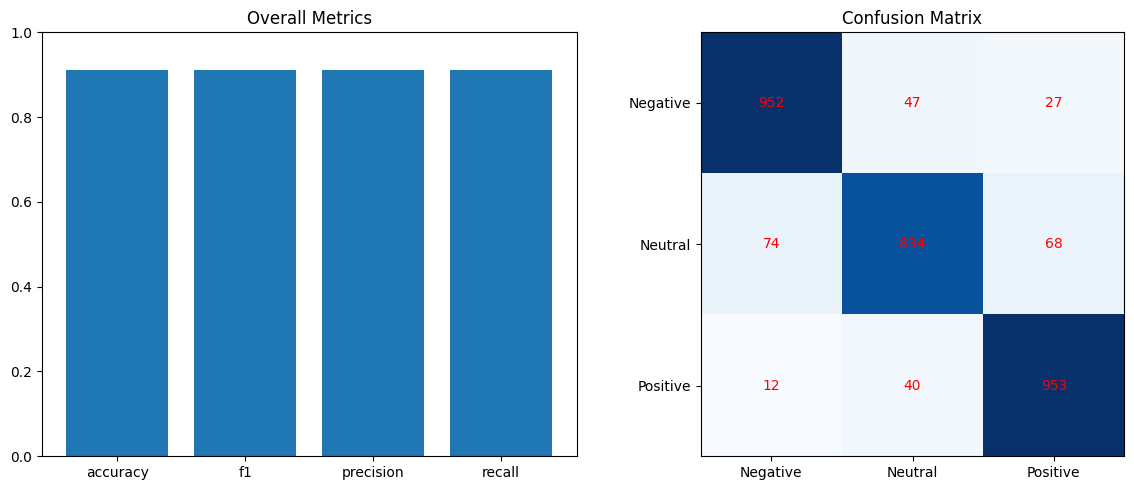

In [ ]:
def plot_results(metrics, confusion_matrix):
    """Create plots for thesis"""
    # Accuracy and F1 plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Metrics plot
    metrics_to_plot = ['accuracy', 'f1', 'precision', 'recall']
    values = [metrics[m] for m in metrics_to_plot]
    ax1.bar(metrics_to_plot, values)
    ax1.set_title('Overall Metrics')
    ax1.set_ylim(0, 1)

    # Confusion matrix heatmap
    im = ax2.imshow(confusion_matrix, cmap='Blues')
    ax2.set_xticks([0, 1, 2])
    ax2.set_yticks([0, 1, 2])
    ax2.set_xticklabels(['Negative', 'Neutral', 'Positive'])
    ax2.set_yticklabels(['Negative', 'Neutral', 'Positive'])
    ax2.set_title('Confusion Matrix')

    # Add values to confusion matrix
    for i in range(3):
        for j in range(3):
            ax2.text(j, i, confusion_matrix[i, j],
                    ha='center', va='center', color='red')

    plt.tight_layout()
    plt.savefig('banglabert_results.png', dpi=300, bbox_inches='tight')
    plt.show()

# Generate plots
plot_results(test_metrics, confusion_matrix)